# 02 — Pré-processamento

Transforma as duas tabelas brutas no dataset de modelagem. Cada decisão abaixo responde a um achado do notebook 01.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import GROUP, JANELA_MESES, PROCESSED_FILE, RANDOM_STATE, TARGET  # semente fixa: 42
from src.data import add_target, build_accounts, load_raw, save_processed
from src.evaluation import save_table
from src.preprocessing import (
    CADASTRAIS, CATEGORICAS, HISTORICO,
    add_application_features, add_history_features, check_missing,
)
from src.viz import AZUL, save, set_style

set_style()
pd.set_option("display.max_columns", None)
print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


In [2]:
app, credit = load_raw()
base = build_accounts(app, credit)
print(f"Base de contas: {base.shape[0]:,} linhas | proponentes distintos: {base[GROUP].nunique():,}")

Base de contas: 36,457 linhas | proponentes distintos: 9,728


## 1. Dados faltantes

In [3]:
display(check_missing(base[app.columns]))

sem_ocupacao = base["OCCUPATION_TYPE"].isna()
print("Ocupação ausente por origem da renda (%):")
print((base.groupby("NAME_INCOME_TYPE")["OCCUPATION_TYPE"].apply(lambda s: s.isna().mean()) * 100).round(1).to_string())
print(f"\nTaxa de atraso 60+ | ocupação ausente: {base.loc[sem_ocupacao, 'target_qualquer_momento'].mean():.2%}"
      f" | ocupação informada: {base.loc[~sem_ocupacao, 'target_qualquer_momento'].mean():.2%}")

,nulos,pct
OCCUPATION_TYPE,11323,31.06


Ocupação ausente por origem da renda (%):
NAME_INCOME_TYPE
Commercial associate    16.9
Pensioner               99.8
State servant           18.4
Student                  9.1
Working                 17.0

Taxa de atraso 60+ | ocupação ausente: 1.71% | ocupação informada: 1.68%


**Decisão:** preencher `OCCUPATION_TYPE` com a categoria `Nao informado`.

A ocupação é a única variável original com ausentes (31,06%). A ausência não é aleatória: 99,8% dos pensionistas não têm ocupação informada, contra 9% a 18% nos demais grupos. Faz sentido, já que pensionista não exerce ocupação. Descartar essas linhas eliminaria um terço da base e praticamente todos os pensionistas; imputar a ocupação mais frequente inventaria um emprego para quem não tem. Uma categoria própria preserva a informação. A taxa de atraso grave é praticamente a mesma com ou sem ocupação informada (1,71% e 1,68%), então a ausência em si não indica risco.

## 2. Definição da variável alvo

In [4]:
linhas = []
for janela in (6, 12, 18, 24):
    d = add_target(base, janela)
    linhas.append({"janela_meses": janela, "contas": len(d), "maus": int(d[TARGET].sum()),
                   "taxa_maus_%": round(d[TARGET].mean() * 100, 2),
                   "%_da_base_mantida": round(len(d) / len(base) * 100, 1)})
display(pd.DataFrame(linhas).set_index("janela_meses"))

df = add_target(base, JANELA_MESES)
print(f"Janela adotada: {JANELA_MESES} meses -> {len(df):,} contas, {int(df[TARGET].sum())} más ({df[TARGET].mean():.2%})")

,contas,maus,taxa_maus_%,%_da_base_mantida
janela_meses,,,,
6,32567,228,0.70,89.3
12,27638,394,1.43,75.8
18,22954,407,1.77,63.0
24,18850,377,2.00,51.7


Janela adotada: 12 meses -> 27,638 contas, 394 más (1.43%)


**Alvo:** `target = 1` se a conta atingiu `STATUS` 2, 3, 4 ou 5 (atraso de 60 dias ou mais) em algum dos primeiros 12 meses após a abertura. Só entram contas com pelo menos 12 meses de observação.

A binarização tem dois limiares, ambos escolhidos pela distribuição vista no notebook 01:

- **Gravidade, 60 dias:** atrasos de até 29 dias aparecem em 37% dos registros mensais e não distinguem ninguém. A partir de 60 dias o evento é raro (0,30% dos registros) e representa inadimplência de fato.
- **Janela, 12 meses:** a tabela mostra o custo de cada opção. Com 6 meses sobram só 228 contas más, porque a maioria dos atrasos ainda não aconteceu. Com 24 meses perde-se quase metade da base. Doze meses mantêm 75,8% das contas e capturam 394 contas más (1,43%).

Contas com menos de 12 meses são excluídas, e não rotuladas como boas: ainda não se sabe o que elas são.

## 3. Normalização / padronização

In [5]:
df = add_application_features(df)
df[["AMT_INCOME_TOTAL", "RENDA_PER_CAPITA", "IDADE_ANOS", "ANOS_EMPREGO", "CNT_FAM_MEMBERS"]].describe().T[
    ["mean", "std", "min", "50%", "max"]].round(1)

,mean,std,min,50%,max
AMT_INCOME_TOTAL,188314.1,101591.0,27000.0,162000.0,1575000.0
RENDA_PER_CAPITA,100591.0,72353.5,7560.0,78750.0,900000.0
IDADE_ANOS,43.9,11.3,21.2,42.8,68.9
ANOS_EMPREGO,6.2,6.6,0.0,4.5,43.0
CNT_FAM_MEMBERS,2.2,0.9,1.0,2.0,15.0


**Escolha:** `StandardScaler`, aplicado apenas nos modelos que dependem de escala (Regressão Logística e Naive Bayes), e **dentro do `Pipeline`** no notebook 03.

As variáveis têm ordens de grandeza muito diferentes: renda na casa das centenas de milhares, idade em dezenas, tamanho da família em unidades. Na regressão logística com regularização, uma variável em escala maior recebe penalização desproporcional; padronizar coloca todas em média 0 e desvio 1. Modelos de árvore decidem por ordenação e não mudam com a escala, por isso recebem os dados sem padronizar.

Nada é escalado neste notebook de propósito. Ajustar o scaler aqui usaria média e desvio do conjunto inteiro, incluindo o teste. No pipeline, ele é ajustado só nos dados de treino de cada fold.

## 4. Feature engineering

### 4.1 Variáveis do formulário

In [6]:
display(df[["DAYS_BIRTH", "IDADE_ANOS", "DAYS_EMPLOYED", "ANOS_EMPREGO", "SEM_VINCULO",
            "AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "RENDA_PER_CAPITA", "OCCUPATION_TYPE"]].head(4).round(1))
print("FLAG_MOBIL tem um único valor:", df["FLAG_MOBIL"].unique().tolist(), "-> descartada")

,DAYS_BIRTH,IDADE_ANOS,DAYS_EMPLOYED,ANOS_EMPREGO,SEM_VINCULO,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,RENDA_PER_CAPITA,OCCUPATION_TYPE
0,-12005,32.9,-4542,12.4,0,427500.0,2.0,213750.0,Nao informado
1,-12005,32.9,-4542,12.4,0,427500.0,2.0,213750.0,Nao informado
2,-21474,58.8,-1134,3.1,0,112500.0,2.0,56250.0,Security staff
3,-19110,52.3,-3051,8.4,0,270000.0,1.0,270000.0,Sales staff


FLAG_MOBIL tem um único valor: [1] -> descartada


| Variável criada | Como | Por quê |
|---|---|---|
| `IDADE_ANOS` | `-DAYS_BIRTH / 365,25` | legibilidade |
| `ANOS_EMPREGO` | `-DAYS_EMPLOYED / 365,25`; zero para quem não tem vínculo | remove o código 365243 |
| `SEM_VINCULO` | 1 quando `DAYS_EMPLOYED` é o código 365243 | preserva a informação que o código carregava |
| `RENDA_PER_CAPITA` | renda / pessoas na família | a mesma renda sustenta famílias de tamanhos diferentes |

`FLAG_MOBIL` é descartada por ser constante. `DAYS_BIRTH` e `DAYS_EMPLOYED` são substituídas pelas versões em anos. As categóricas seguem como texto e são codificadas (one-hot) dentro do pipeline.

Fomos contidos de propósito: o notebook 01 mostrou que as variáveis do formulário quase não se relacionam com o alvo, e combinações entre elas não criam informação que não existe. O ganho está na próxima seção.

### 4.2 Histórico interno do proponente

O notebook 01 mostrou que a maioria dos proponentes tem mais de uma conta, abertas em meses diferentes. Quando um cliente pede um novo cartão, o banco já conhece como ele pagou os cartões anteriores. Essa é a informação que construímos aqui, com uma regra rígida: **só entram registros de outras contas do mesmo proponente, datados antes do mês de abertura da conta analisada**.

In [7]:
df = add_history_features(df, credit)

# Verificação da regra temporal em uma conta com histórico.
exemplo = df[(df["HIST_CONTAS"] >= 2) & (df["HIST_MESES_ATRASO"] > 0)].iloc[0]
usados = credit[credit["ID"].isin(base.loc[base[GROUP] == exemplo[GROUP], "ID"])
                & (credit["ID"] != exemplo["ID"])
                & (credit["MONTHS_BALANCE"] < exemplo["MES_ABERTURA"])]
print(f"Conta {exemplo['ID']}: aberta no mês {exemplo['MES_ABERTURA']}.")
print(f"Registros usados no histórico: {len(usados)} (HIST_MESES = {int(exemplo['HIST_MESES'])}), "
      f"do mês {usados['MONTHS_BALANCE'].min()} ao mês {usados['MONTHS_BALANCE'].max()}.")
assert len(usados) == exemplo["HIST_MESES"] and usados["MONTHS_BALANCE"].max() < exemplo["MES_ABERTURA"]

print(f"\nContas com histórico anterior: {df['TEM_HISTORICO'].mean():.0%}")
display(df.loc[df["TEM_HISTORICO"] == 1, HISTORICO].describe().T[["mean", "50%", "max"]].round(2))

Conta 5008813: aberta no mês -16.
Registros usados no histórico: 5 (HIST_MESES = 5), do mês -20 ao mês -17.

Contas com histórico anterior: 65%


,mean,50%,max
TEM_HISTORICO,1.00,1.00,1.0
HIST_CONTAS,3.36,3.00,31.0
HIST_MESES,43.58,26.00,463.0
HIST_TEMPO_CASA,19.41,18.00,48.0
HIST_PIOR_STATUS,1.14,1.00,6.0
HIST_PIOR_STATUS_6M,0.89,1.00,6.0
HIST_MESES_ATRASO,20.52,13.00,227.0
HIST_MESES_ATRASO_30,0.53,0.00,70.0
HIST_TEVE_ATRASO_60,0.02,0.00,1.0
HIST_TAXA_ATRASO,0.56,0.55,1.0


| Variável | O que mede |
|---|---|
| `TEM_HISTORICO` | o proponente já tinha alguma conta antes desta |
| `HIST_CONTAS` | quantas contas anteriores |
| `HIST_MESES` | total de meses de histórico nessas contas |
| `HIST_TEMPO_CASA` | meses desde a primeira conta até esta abertura |
| `HIST_PIOR_STATUS` | pior situação já registrada (0 = em dia ... 6 = 150+ dias) |
| `HIST_PIOR_STATUS_6M` | pior situação nos 6 meses antes da abertura |
| `HIST_MESES_ATRASO`, `HIST_MESES_ATRASO_30` | meses com qualquer atraso / com atraso de 30+ dias |
| `HIST_TEVE_ATRASO_60` | já teve atraso de 60+ dias |
| `HIST_TAXA_ATRASO` | proporção dos meses com algum atraso |
| `HIST_TAXA_QUITADO`, `HIST_TAXA_SEM_USO` | proporção dos meses quitados / sem uso |

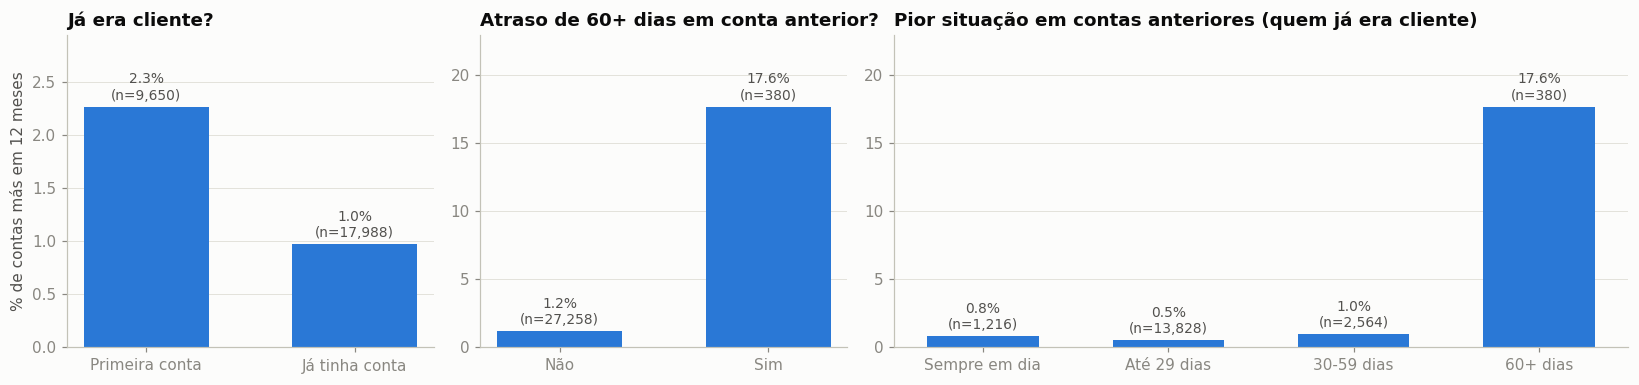

contas  \
Já era cliente?                                    Primeira conta    9650   
                                                   Já tinha conta   17988   
Atraso de 60+ dias em conta anterior?              Não              27258   
                                                   Sim                380   
Pior situação em contas anteriores (quem já era... Sempre em dia     1216   
                                                   Até 29 dias      13828   
                                                   30-59 dias        2564   
                                                   60+ dias           380   

                                                                   taxa_maus  
Já era cliente?                                    Primeira conta     0.0227  
                                                   Já tinha conta     0.0097  
Atraso de 60+ dias em conta anterior?              Não                0.0120  
                                                   Sim                0.1763  
Pior situação em contas anteriores (quem já era... Sempre em dia      0.0082  
                                                   Até 29 dias        0.0053  
                                                   30-59 dias         0.0098  
                                                   60+ dias           0.1763

In [8]:
def taxa_por(coluna, rotulos):
    t = df.loc[coluna.index if isinstance(coluna, pd.Series) else df.index].groupby(coluna)[TARGET].agg(["size", "mean"])
    t.index = [rotulos.get(i, str(i)) for i in t.index]
    return t

paineis = [
    ("Já era cliente?", taxa_por("TEM_HISTORICO", {0: "Primeira conta", 1: "Já tinha conta"})),
    ("Atraso de 60+ dias em conta anterior?", taxa_por("HIST_TEVE_ATRASO_60", {0: "Não", 1: "Sim"})),
    ("Pior situação em contas anteriores (quem já era cliente)",
     taxa_por(df.loc[df["TEM_HISTORICO"] == 1, "HIST_PIOR_STATUS"].clip(upper=3).astype(int),
              {0: "Sempre em dia", 1: "Até 29 dias", 2: "30-59 dias", 3: "60+ dias"})),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), gridspec_kw={"width_ratios": [2, 2, 4]})
for ax, (titulo, t) in zip(axes, paineis):
    ax.bar(t.index, t["mean"] * 100, color=AZUL, width=0.6)
    for x, (n, v) in enumerate(zip(t["size"], t["mean"] * 100)):
        ax.text(x, v + (t["mean"] * 100).max() * 0.03, f"{v:.1f}%\n(n={n:,})", ha="center", color="#52514e", fontsize=9)
    ax.set_title(titulo)
    ax.set_ylim(0, (t["mean"] * 100).max() * 1.3)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel(f"% de contas más em {JANELA_MESES} meses")
plt.tight_layout()
save(fig, "02_historico_vs_alvo")
plt.show()

resumo_historico = pd.concat({titulo: t for titulo, t in paineis}).rename(columns={"size": "contas", "mean": "taxa_maus"})
display(save_table(resumo_historico.round(4), "taxa_por_historico"))

O gráfico confirma que o histórico interno carrega sinal, e que o formulário não tinha:

- **Cliente novo é mais arriscado.** 35% das contas são a primeira do proponente, e 2,3% delas atrasam gravemente em 12 meses. Entre quem já tinha conta, a taxa é 1,0%.
- **Atraso grave anterior é o sinal mais forte.** Quem já atrasou 60 dias ou mais em outro cartão volta a atrasar em 17,6% dos casos, contra 1,2% dos demais. São só 380 contas, mas com risco quase 15 vezes maior.
- **Atraso leve não é sinal de risco.** Entre quem já era cliente, quem teve no máximo atrasos de até 29 dias atrasa gravemente em 0,5% dos casos, menos que quem esteve sempre em dia ou sem uso (0,8%). O `STATUS` 0 parece refletir uso normal do cartão, e não dificuldade de pagamento.

**Por que isto não é vazamento.** O alvo olha para a própria conta, do mês de abertura em diante. O histórico olha para outras contas, antes do mês de abertura. Os dois períodos não se sobrepõem, e a célula acima verifica isso em um caso concreto. No momento do pedido, o banco teria exatamente essa informação.

A limitação é direta: para os 35% que pedem o primeiro cartão, todas as variáveis de histórico valem zero. O notebook 04 mede o desempenho do modelo separadamente nesse grupo.

## 5. Salvar dataset tratado

In [9]:
features = CADASTRAIS + CATEGORICAS + HISTORICO
final = df[["ID", GROUP, "MES_ABERTURA"] + features + [TARGET]]
assert final[features].isna().sum().sum() == 0

save_processed(final)
print(f"Dataset tratado: {final.shape[0]:,} linhas x {final.shape[1]} colunas -> {PROCESSED_FILE.relative_to(ROOT)}")
print(f"Features: {len(CADASTRAIS)} numéricas de cadastro, {len(CATEGORICAS)} categóricas, {len(HISTORICO)} de histórico")

Dataset tratado: 27,638 linhas x 34 colunas -> data/processed/dataset_tratado.csv
Features: 10 numéricas de cadastro, 8 categóricas, 12 de histórico
